In [193]:
import pandas as pd
import matplotlib.pyplot as plt

In [194]:
diabetes = "/Users/kimberlybrooks/Desktop/PythonSemester2/Diabetes.txt"


In [195]:
diabetes = pd.read_csv(diabetes, header = 0)

In [ ]:
#Checking out the data 

#diabetes.head()
#diabetes.info()
#diabetes.columns



# **TASK 1**

In [197]:
# Need to convert these values in Cases column to integers 
diabetes['Cases '] = diabetes['Cases '].astype(int)
diabetes['Cases '].unique()

array([ 180,  160,  190,  220,  200,  210,  230,  170,  240,  250, 1300,
        260,  270, 1000, 1200,  280])

In [208]:
# Total cases: How many total chronic disease cases (e.g., diabetes) were newly diagnosed each year?

new_cases = diabetes.groupby('Year')['Cases '].sum()
new_cases


Year
2011     750
2012     830
2013     710
2014     900
2015     840
2016     830
2017     940
2018    2010
2019     980
2020    2750
Name: Cases , dtype: int64

In [213]:
#In how many quarters did the number of new cases exceed 200?
quarter_counts = diabetes[diabetes['Cases '] > 200]['Quarter'].value_counts()
quarter_counts

Quarter
4    9
3    7
2    6
1    6
Name: count, dtype: int64

In [229]:
#In which quarters did the cases exceed 200? 
quarter_cases = diabetes[diabetes['Cases '] > 200]
quarter_cases.head()


,Year,Quarter,Cases
3,2011,4,220
5,2012,2,210
7,2012,4,230
12,2014,1,220
13,2014,2,210


In [207]:
# What was the average number of new cases across the quarters for each year? 

avg_cases = diabetes.groupby('Year')['Cases '].mean()
avg_cases

Year
2011    187.5
2012    207.5
2013    177.5
2014    225.0
2015    210.0
2016    207.5
2017    235.0
2018    502.5
2019    245.0
2020    687.5
Name: Cases , dtype: float64

# **Task 2**

In [141]:
#What was the average number of new cases reported for each quarter across all years?

avg_cases_per_quarter = diabetes.groupby('Quarter')['Cases '].mean()
avg_cases_per_quarter


Quarter
1    324.0
2    280.0
3    312.0
4    238.0
Name: Cases , dtype: float64

In [227]:
# In which year were the most diabetes cases reported?

total_cases_per_year = diabetes.groupby('Year')['Cases '].sum()

#max number of cases
most_new_cases_value = total_cases_per_year.max()
most_new_cases_year = total_cases_per_year.idxmax()

print( "Year:", most_new_cases_year , "Cases:", most_new_cases_value)



Year: 2020 Cases: 2750


In [228]:
# In which year were the least diabetes cases reported?

total_cases_per_year = diabetes.groupby('Year')['Cases '].sum()

least_new_cases_value = total_cases_per_year.min()
least_new_cases_year = total_cases_per_year.idxmin()

print( "Year:", least_new_cases_year , "Cases:", least_new_cases_value)

Year: 2013 Cases: 710


# **Task 3**

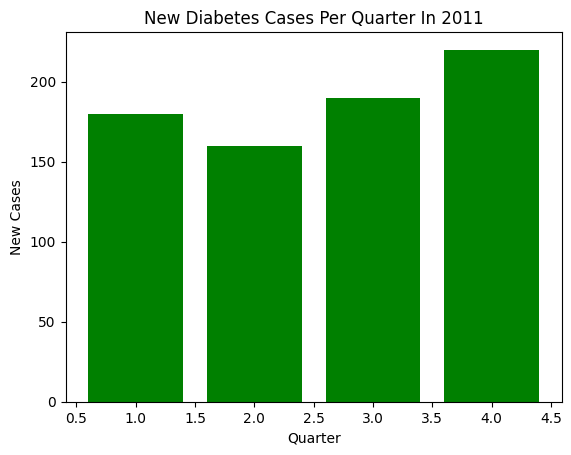

In [231]:
#Selected year : 2011

diabetes_2011 = diabetes[diabetes['Year'] == 2011]

#print(diabetes_2011)

y = diabetes_2011['Cases '].unique()

x = diabetes_2011['Quarter'].unique()

plt.bar(x,y, color = "green")
plt.xlabel('Quarter')
plt.ylabel('New Cases')
plt.title('New Diabetes Cases Per Quarter In 2011')

plt.show()






Answer: Quarter 4 in 2011 showed the highest number of cases

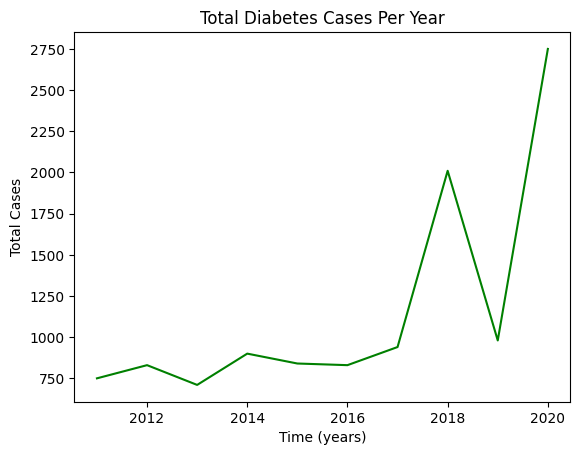

In [247]:
#Total mumber of cases per year
total_cases_per_year = diabetes.groupby('Year')['Cases '].sum()

#print(total_cases_per_year)

x = total_cases_per_year.index
y = total_cases_per_year.values

plt.plot(x,y, color ='green', ls = '-')
plt.xlabel('Time (years)')
plt.ylabel('Total Cases')
plt.title('Total Diabetes Cases Per Year')
plt.show()



Answer: Overall, the graph shows that there has been a marked increase in new cases of diabetes over the 10 year period, from 750 cases in 2011 to 2750 cases in 2020. Of note, there was a sharp decline in cases, dropping from 2000 cases in 2018 to 1000 cases in 2019, however it rapidly incrased to record highs in 2020. 

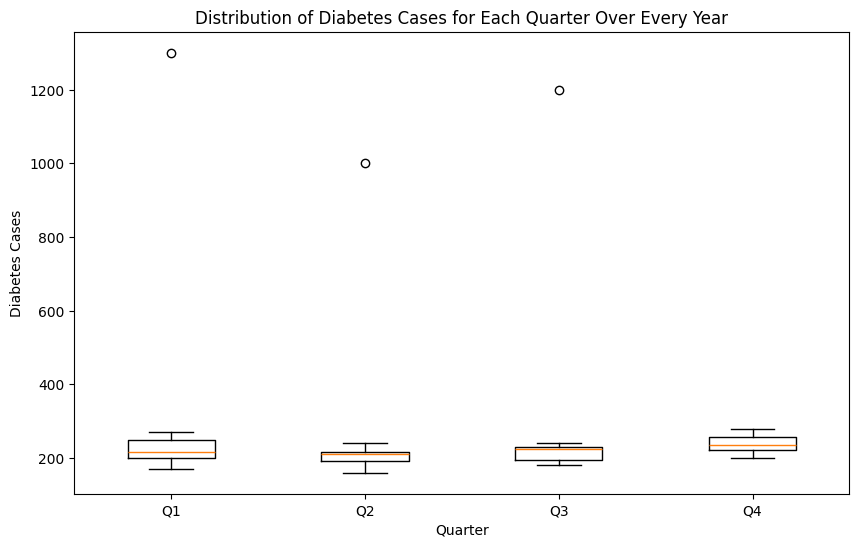

In [248]:
# Group by 'Quarter' and collect all cases in a list
quarter_cases = diabetes.groupby('Quarter')['Cases '].apply(list).reset_index()

# Create the box plot directly from the grouped data
plt.figure(figsize=(10, 6))
plt.boxplot(quarter_cases['Cases '], tick_labels=['Q1', 'Q2', 'Q3', 'Q4'])


plt.title('Distribution of Diabetes Cases for Each Quarter Over Every Year')
plt.xlabel('Quarter')
plt.ylabel('Diabetes Cases')

# Show the plot
plt.show()

Answer: There are significant outliers noted in quarters one, two and three. The outliers could signify events that are leading to an increase in dagnosis rates like more testing due to end of year required check ups. Or errors in data collection. 